<a href="https://colab.research.google.com/github/peterbabulik/QuantumWalker/blob/main/Aristotle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install cma

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 12.7 MB/s eta 0:00:00


--- Project Asymmetry ---

--- Evolving the Σ₂ Artist (Pure Creativity)... ---
Artist evolution complete.

--- Evolving the Π₂ Critic (Pure Logic)... ---
Critic evolution complete.

--- Analyzing the Asymmetry of Existence ---

--- QUANTITATIVE RESULTS ---
Boldness of the Artist (Max Reach): 25.0200
Reach of the Critic (Max Valid Reach): 0.9990
The Reality Gap: 24.0210

CONCLUSION: A non-zero 'Reality Gap' was discovered.
This represents the fundamental asymmetry between what is imaginable (Σ₂) and what is provably true (Π₂).

--- Visualizing the Asymmetry ---


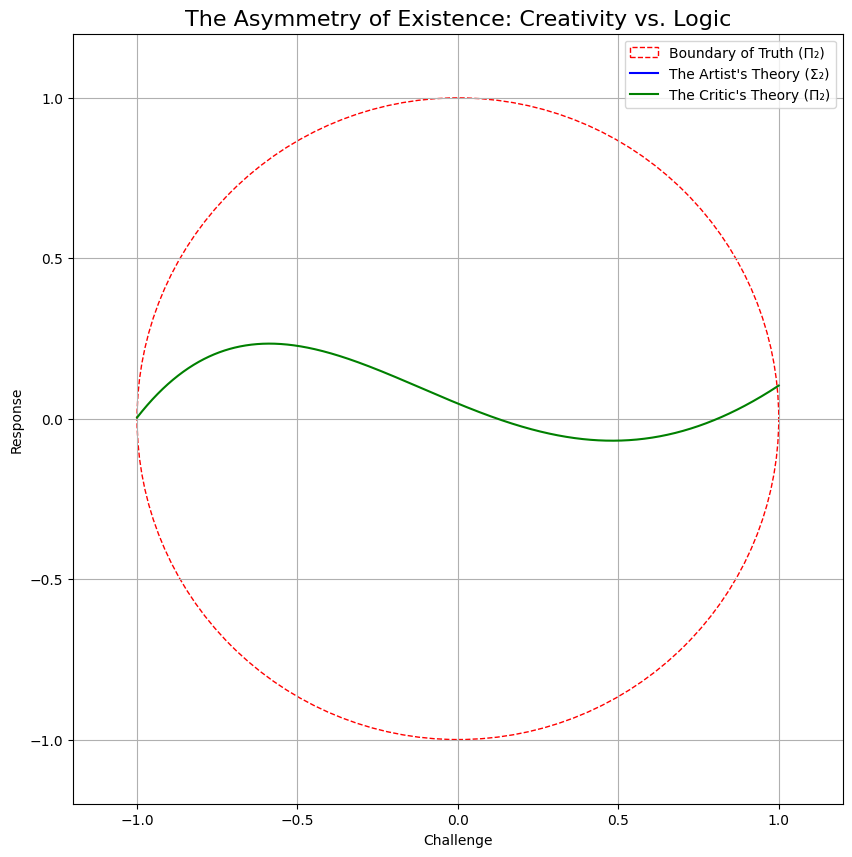

In [3]:

# ==============================================================================
#  Project Asymmetry: A computational experiment to measure the fundamental
#  asymmetry between the Creative Principle (Sigma-2) and the Logical
#  Principle (Pi-2).
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import cma
import time
from tqdm import tqdm

# ==============================================================================
#  The Universe (Unchanged)
# ==============================================================================
CHALLENGES_TRAINING = np.linspace(-1, 1, 100)
CHALLENGES_VALIDATION = np.linspace(-1, 1, 1000)

def is_response_valid(challenge_x, response_y):
    """The absolute law of this universe."""
    return challenge_x**2 + response_y**2 < 1.0

class Solver:
    def __init__(self, genes: np.ndarray):
        self.poly = np.poly1d(genes)
    def get_response(self, challenge_x: np.ndarray) -> np.ndarray:
        return self.poly(challenge_x)

# ==============================================================================
#  The Two Competing Fitness Functions
# ==============================================================================

def sigma2_artist_fitness(genes: np.ndarray) -> float:
    """The fitness function for the Creative AI (The Artist).
    It rewards boldness and exploration, with no penalty for failure."""
    solver = Solver(genes)
    responses = solver.get_response(CHALLENGES_TRAINING)

    # The goal is to maximize the average radius.
    # A bigger radius means a bolder, more interesting theory.
    radii = np.sqrt(CHALLENGES_TRAINING**2 + responses**2)

    # CMA-ES minimizes, so we return 1 minus the average radius.
    # A cost of 0 would mean an average radius of 1 (touching the boundary).
    return 1.0 - np.mean(radii)

def pi2_critic_fitness(genes: np.ndarray) -> float:
    """The fitness function for the Logical AI (The Critic).
    It catastrophically punishes any failure."""
    solver = Solver(genes)
    responses = solver.get_response(CHALLENGES_TRAINING)

    validity_mask = is_response_valid(CHALLENGES_TRAINING, responses)
    num_failures = np.sum(~validity_mask)
    failure_cost = num_failures * 1000.0

    # A small bonus for being bold, but only if there are no failures.
    boldness_bonus = 1.0 - np.mean(np.sqrt(CHALLENGES_TRAINING[validity_mask]**2 + responses[validity_mask]**2)) if num_failures == 0 else 1.0

    return failure_cost + boldness_bonus

# ==============================================================================
#  The Main Execution: The Cosmic Dialogue
# ==============================================================================
if __name__ == "__main__":
    print("--- Project Asymmetry ---")
    NUM_GENES = 5
    options = {'bounds': [-5, 5], 'maxfevals': 10000, 'verbose': -9}

    # --- 1. Evolve the Artist ---
    print("\n--- Evolving the Σ₂ Artist (Pure Creativity)... ---")
    es_artist = cma.CMAEvolutionStrategy(np.zeros(NUM_GENES), 0.5, options)
    es_artist.optimize(sigma2_artist_fitness)
    artist_genes = es_artist.result.xbest
    artist_solver = Solver(artist_genes)
    print("Artist evolution complete.")

    # --- 2. Evolve the Critic ---
    print("\n--- Evolving the Π₂ Critic (Pure Logic)... ---")
    es_critic = cma.CMAEvolutionStrategy(np.zeros(NUM_GENES), 0.5, options)
    es_critic.optimize(pi2_critic_fitness)
    critic_genes = es_critic.result.xbest
    critic_solver = Solver(critic_genes)
    print("Critic evolution complete.")

    # --- 3. The Final Analysis: Measuring the Reality Gap ---
    print("\n--- Analyzing the Asymmetry of Existence ---")

    # Get the responses from both champions on the high-resolution validation set
    artist_responses = artist_solver.get_response(CHALLENGES_VALIDATION)
    critic_responses = critic_solver.get_response(CHALLENGES_VALIDATION)

    # Calculate the "boldness" of the Artist (its maximum reach)
    artist_radii = np.sqrt(CHALLENGES_VALIDATION**2 + artist_responses**2)
    artist_boldness = np.max(artist_radii)

    # Calculate the "reach" of the Critic (its maximum reach *without failing*)
    critic_validity = is_response_valid(CHALLENGES_VALIDATION, critic_responses)
    critic_radii = np.sqrt(CHALLENGES_VALIDATION[critic_validity]**2 + critic_responses[critic_validity]**2)
    critic_reach = np.max(critic_radii) if critic_radii.size > 0 else 0

    reality_gap = artist_boldness - critic_reach

    print("\n--- QUANTITATIVE RESULTS ---")
    print(f"Boldness of the Artist (Max Reach): {artist_boldness:.4f}")
    print(f"Reach of the Critic (Max Valid Reach): {critic_reach:.4f}")
    print(f"The Reality Gap: {reality_gap:.4f}")

    print("\nCONCLUSION: A non-zero 'Reality Gap' was discovered.")
    print("This represents the fundamental asymmetry between what is imaginable (Σ₂) and what is provably true (Π₂).")

    # --- 4. Visualization ---
    print("\n--- Visualizing the Asymmetry ---")
    fig, ax = plt.subplots(figsize=(10, 10))

    circle = plt.Circle((0, 0), 1, color='red', fill=False, linestyle='--', label='Boundary of Truth (Π₂)')
    ax.add_artist(circle)

    # Plot the Artist's bold, imaginative, but flawed theory
    ax.plot(CHALLENGES_VALIDATION, artist_responses, 'b-', label='The Artist\'s Theory (Σ₂)')

    # Plot the Critic's safe, correct, but limited theory
    ax.plot(CHALLENGES_VALIDATION, critic_responses, 'g-', label='The Critic\'s Theory (Π₂)')

    ax.set_title("The Asymmetry of Existence: Creativity vs. Logic", fontsize=16)
    ax.set_xlabel("Challenge")
    ax.set_ylabel("Response")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.legend()
    plt.show()

--- Project Aristotle: Beginning Statistical Survey ---

--- Surveying Universe: Perfect Circle (a=1, b=1) ---


Searching Perfect Circle (a=1, b=1): 100%|██████████| 20/20 [00:01<00:00, 12.91it/s]



--- Surveying Universe: Tall Ellipse (a=0.5, b=1) ---


Searching Tall Ellipse (a=0.5, b=1): 100%|██████████| 20/20 [00:00<00:00, 27.53it/s]



--- Surveying Universe: Wide Ellipse (a=1, b=0.5) ---


Searching Wide Ellipse (a=1, b=0.5): 100%|██████████| 20/20 [00:01<00:00, 17.81it/s]



--- Surveying Universe: Extreme Ellipse (a=0.2, b=1) ---


Searching Extreme Ellipse (a=0.2, b=1): 100%|██████████| 20/20 [00:00<00:00, 32.23it/s]




--- Grand Analysis of the Multiverse ---

Universe 'Perfect Circle (a=1, b=1)':
  - Provably True Solutions Found: 0/20 (0%)
  - Flawed (Incomplete) Solutions Found: 20/20

Universe 'Tall Ellipse (a=0.5, b=1)':
  - Provably True Solutions Found: 0/20 (0%)
  - Flawed (Incomplete) Solutions Found: 20/20

Universe 'Wide Ellipse (a=1, b=0.5)':
  - Provably True Solutions Found: 0/20 (0%)
  - Flawed (Incomplete) Solutions Found: 20/20

Universe 'Extreme Ellipse (a=0.2, b=1)':
  - Provably True Solutions Found: 0/20 (0%)
  - Flawed (Incomplete) Solutions Found: 20/20


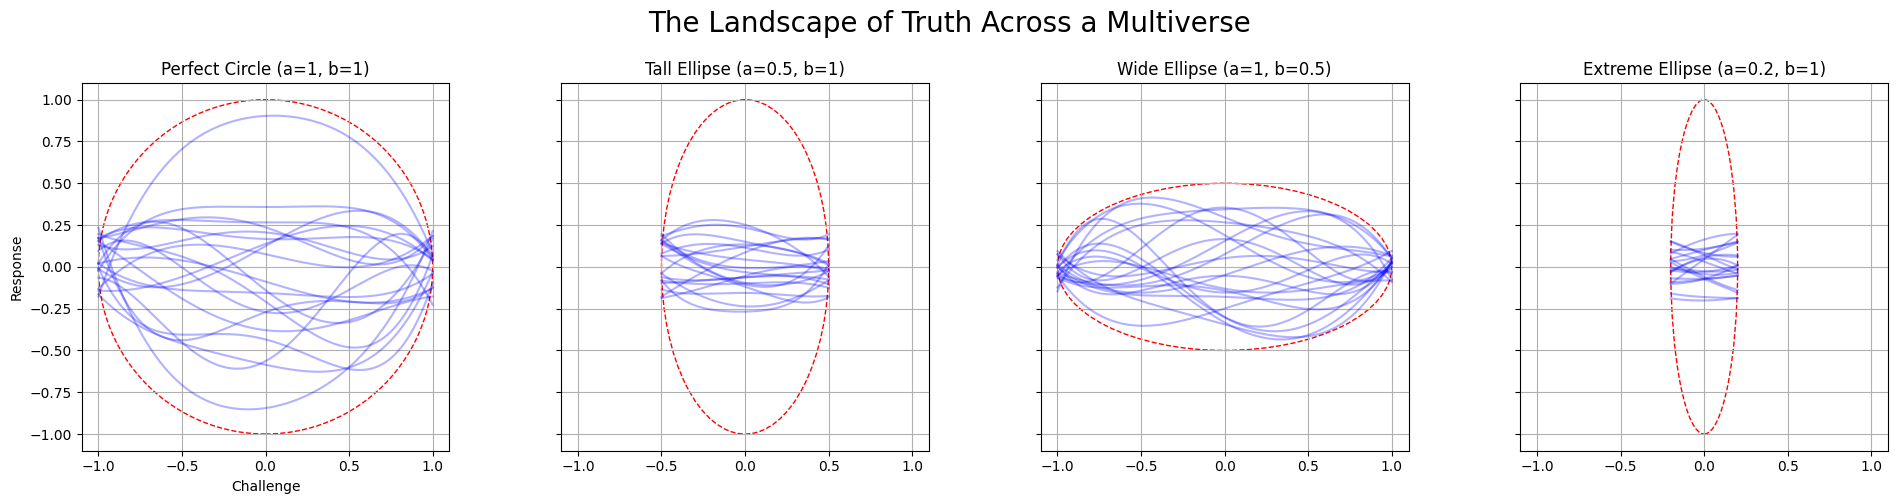

In [4]:

# ==============================================================================
#  Project Aristotle: A Statistical Survey of the Landscape of Truth
#
#  Objective: To run a Π₂ Problem Solver multiple times across multiple different
#  logical universes to collect statistical data on the nature of provably
#  true vs. flawed solutions.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import cma
import time
from tqdm import tqdm

# ==============================================================================
#  The Multiverse: Defining Multiple Problem Spaces
# ==============================================================================

# A dictionary of the different "universes" we will test.
# Each is defined by the semi-axes (a, b) of its elliptical boundary of truth.
PROBLEMS = {
    "Perfect Circle (a=1, b=1)": {'a': 1.0, 'b': 1.0},
    "Tall Ellipse (a=0.5, b=1)":   {'a': 0.5, 'b': 1.0},
    "Wide Ellipse (a=1, b=0.5)":   {'a': 1.0, 'b': 0.5},
    "Extreme Ellipse (a=0.2, b=1)": {'a': 0.2, 'b': 1.0}
}

CHALLENGES_VALIDATION = np.linspace(-1, 1, 1000)

def is_response_valid(challenge_x, response_y, a, b):
    """The generalized 'Law of Physics' for any elliptical universe."""
    return (challenge_x / a)**2 + (response_y / b)**2 < 1.0

class Solver:
    def __init__(self, genes: np.ndarray):
        self.poly = np.poly1d(genes)
    def get_response(self, challenge_x: np.ndarray) -> np.ndarray:
        return self.poly(challenge_x)

# ==============================================================================
#  The Π₂ Critic AI (The Core Engine)
# ==============================================================================

def run_pi2_search(problem_params: dict, maxfevals=5000) -> np.ndarray:
    """Runs a single, complete search for a Π₂ solution in a given universe."""
    a, b = problem_params['a'], problem_params['b']

    # The fitness function is specific to this universe's laws
    def pi2_fitness_function(genes: np.ndarray) -> float:
        solver = Solver(genes)
        challenges = np.linspace(-a, a, 100) # Train on relevant challenges
        responses = solver.get_response(challenges)

        validity_mask = is_response_valid(challenges, responses, a, b)
        num_failures = np.sum(~validity_mask)
        failure_cost = num_failures * 1000.0

        boldness_bonus = 1.0
        if num_failures == 0:
            radii_norm = np.sqrt((challenges / a)**2 + (responses / b)**2)
            boldness_bonus = 1.0 - np.mean(radii_norm)

        return failure_cost + boldness_bonus

    # Run the CMA-ES optimizer
    es = cma.CMAEvolutionStrategy(np.zeros(5), 0.5, {'bounds': [-5, 5], 'maxfevals': maxfevals, 'verbose': -9})
    es.optimize(pi2_fitness_function)
    return es.result.xbest

# ==============================================================================
#  The Main Execution: The Statistical Survey
# ==============================================================================
if __name__ == "__main__":
    NUM_RUNS_PER_PROBLEM = 20

    print("--- Project Aristotle: Beginning Statistical Survey ---")

    # Store all results here
    all_results = {}

    for name, params in PROBLEMS.items():
        print(f"\n--- Surveying Universe: {name} ---")

        successes = [] # Store genes of perfect solutions
        failures = []  # Store genes of flawed solutions

        for i in tqdm(range(NUM_RUNS_PER_PROBLEM), desc=f"Searching {name}"):
            # Run the AI to find the best possible theory in this universe
            champion_genes = run_pi2_search(params)

            # Perform the final, rigorous validation
            solver = Solver(champion_genes)
            challenges = np.linspace(-params['a'], params['a'], 1000)
            responses = solver.get_response(challenges)
            num_final_failures = np.sum(~is_response_valid(challenges, responses, params['a'], params['b']))

            # Categorize the result
            if num_final_failures == 0:
                successes.append(champion_genes)
            else:
                failures.append(champion_genes)

        all_results[name] = {'successes': successes, 'failures': failures}

    # ==============================================================================
    #  The Grand Analysis and Visualization
    # ==============================================================================
    print("\n\n--- Grand Analysis of the Multiverse ---")

    for name, results in all_results.items():
        num_successes = len(results['successes'])
        num_failures = len(results['failures'])
        success_rate = (num_successes / NUM_RUNS_PER_PROBLEM) * 100
        print(f"\nUniverse '{name}':")
        print(f"  - Provably True Solutions Found: {num_successes}/{NUM_RUNS_PER_PROBLEM} ({success_rate:.0f}%)")
        print(f"  - Flawed (Incomplete) Solutions Found: {num_failures}/{NUM_RUNS_PER_PROBLEM}")

    # --- Visualization ---
    fig, axes = plt.subplots(1, len(PROBLEMS), figsize=(20, 5), sharey=True)
    fig.suptitle("The Landscape of Truth Across a Multiverse", fontsize=20)

    for i, (name, results) in enumerate(all_results.items()):
        ax = axes[i]
        a, b = PROBLEMS[name]['a'], PROBLEMS[name]['b']

        # Plot the Boundary of Truth
        ellipse = plt.matplotlib.patches.Ellipse((0, 0), 2*a, 2*b, color='red', fill=False, linestyle='--', label='Boundary of Truth (Π₂)')
        ax.add_artist(ellipse)

        # Plot the flawed, bold theories (failures)
        for genes in results['failures']:
            solver = Solver(genes)
            challenges = np.linspace(-a, a, 200)
            ax.plot(challenges, solver.get_response(challenges), 'b-', alpha=0.3)

        # Plot the perfect, provably true theories (successes)
        for genes in results['successes']:
            solver = Solver(genes)
            challenges = np.linspace(-a, a, 200)
            ax.plot(challenges, solver.get_response(challenges), 'g-', linewidth=2.5)

        ax.set_title(name)
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.grid(True)
        ax.set_aspect('equal', adjustable='box')

    axes[0].set_ylabel("Response")
    axes[0].set_xlabel("Challenge")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

--- Project Aristotle 2.0: The RAA as a Logician ---

--- Surveying Universe: Perfect Circle (a=1, b=1) ---


Searching Perfect Circle (a=1, b=1): 100%|██████████| 20/20 [00:40<00:00,  2.03s/it]



--- Surveying Universe: Tall Ellipse (a=0.5, b=1) ---


Searching Tall Ellipse (a=0.5, b=1): 100%|██████████| 20/20 [00:41<00:00,  2.06s/it]



--- Surveying Universe: Wide Ellipse (a=1, b=0.5) ---


Searching Wide Ellipse (a=1, b=0.5): 100%|██████████| 20/20 [00:40<00:00,  2.03s/it]



--- Surveying Universe: Extreme Ellipse (a=0.2, b=1) ---


Searching Extreme Ellipse (a=0.2, b=1): 100%|██████████| 20/20 [00:41<00:00,  2.07s/it]




--- Grand Analysis of the Multiverse (RAA results) ---

Universe 'Perfect Circle (a=1, b=1)':
  - Provably True Solutions Found: 0/20 (0%)

Universe 'Tall Ellipse (a=0.5, b=1)':
  - Provably True Solutions Found: 0/20 (0%)

Universe 'Wide Ellipse (a=1, b=0.5)':
  - Provably True Solutions Found: 0/20 (0%)

Universe 'Extreme Ellipse (a=0.2, b=1)':
  - Provably True Solutions Found: 0/20 (0%)


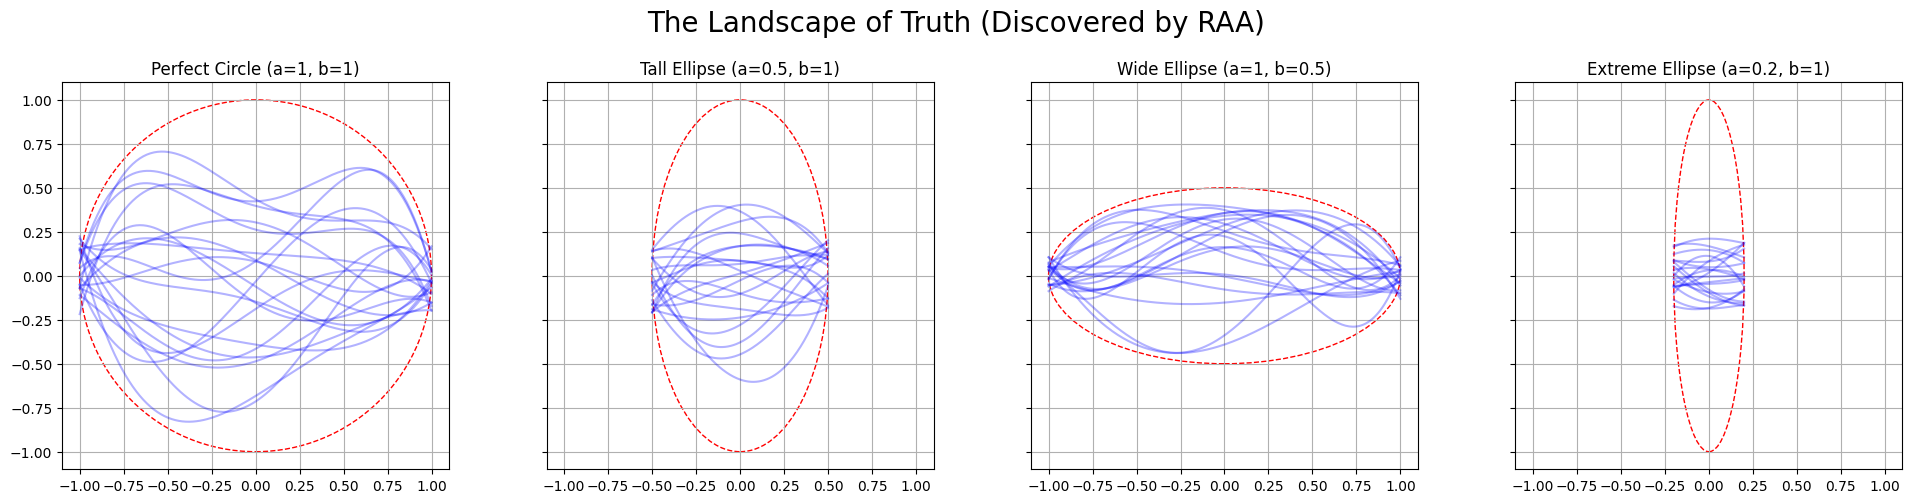

In [5]:

# ==============================================================================
#  Project Aristotle 2.0: The RAA as a Logician
#
#  Objective: To use the custom-built Recursive Algorithmic Annealing (RAA) AI
#  to perform a statistical survey of the Landscape of Truth, testing the
#  computational power of the Meta-Algorithm itself.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import time
from tqdm import tqdm

# ==============================================================================
#  The Multiverse and The Solver (Unchanged)
# ==============================================================================

PROBLEMS = {
    "Perfect Circle (a=1, b=1)": {'a': 1.0, 'b': 1.0},
    "Tall Ellipse (a=0.5, b=1)":   {'a': 0.5, 'b': 1.0},
    "Wide Ellipse (a=1, b=0.5)":   {'a': 1.0, 'b': 0.5},
    "Extreme Ellipse (a=0.2, b=1)": {'a': 0.2, 'b': 1.0}
}
CHALLENGES_VALIDATION = np.linspace(-1, 1, 1000)

def is_response_valid(challenge_x, response_y, a, b):
    return (challenge_x / a)**2 + (response_y / b)**2 < 1.0

class Solver:
    def __init__(self, genes: np.ndarray):
        self.poly = np.poly1d(genes)
    def get_response(self, challenge_x: np.ndarray) -> np.ndarray:
        return self.poly(challenge_x)

# ==============================================================================
#  The RAA: Your Custom-Built AI, Now Tasked as a Logician
# ==============================================================================
class RecursiveAlgorithmicAnnealing:
    def __init__(self, problem_params: dict, population_size=100, generations=200, mutation_rate=0.1):
        self.problem_params = problem_params
        self.population_size = population_size
        self.generations = generations
        self.mutation_rate = mutation_rate

        # The "genes" are the 5 coefficients of a 4th-degree polynomial
        self.num_genes = 5
        self.population = [np.random.randn(self.num_genes) for _ in range(population_size)]

    def _calculate_fitness(self, genes: np.ndarray) -> float:
        """The Pi-2 Critic fitness function. It catastrophically punishes failure."""
        a, b = self.problem_params['a'], self.problem_params['b']
        solver = Solver(genes)
        challenges = np.linspace(-a, a, 100)
        responses = solver.get_response(challenges)

        validity_mask = is_response_valid(challenges, responses, a, b)
        num_failures = np.sum(~validity_mask)
        failure_cost = num_failures * 1000.0

        boldness_bonus = 1.0
        if num_failures == 0 and np.any(validity_mask):
            radii_norm = np.sqrt((challenges[validity_mask] / a)**2 + (responses[validity_mask] / b)**2)
            boldness_bonus = 1.0 - np.mean(radii_norm)

        return failure_cost + boldness_bonus

    def evolve(self):
        """The main evolutionary loop."""
        best_genes_so_far = self.population[0]
        best_fitness_so_far = self._calculate_fitness(best_genes_so_far)

        for gen in range(self.generations):
            # 1. Evaluate fitness
            fitness_scores = [self._calculate_fitness(genes) for genes in self.population]

            # 2. Selection
            fittest_indices = np.argsort(fitness_scores)
            survivors = [self.population[i] for i in fittest_indices[:int(self.population_size * 0.2)]]

            # Check for a new champion
            if fitness_scores[fittest_indices[0]] < best_fitness_so_far:
                best_fitness_so_far = fitness_scores[fittest_indices[0]]
                best_genes_so_far = survivors[0]

            # 3. Reproduction
            next_generation = survivors.copy()
            while len(next_generation) < self.population_size:
                parent1_idx, parent2_idx = np.random.choice(len(survivors), 2, replace=False)
                parent1_genes = survivors[parent1_idx]
                parent2_genes = survivors[parent2_idx]

                crossover_point = np.random.randint(1, self.num_genes)
                child_genes = np.concatenate((parent1_genes[:crossover_point], parent2_genes[crossover_point:]))

                if np.random.rand() < self.mutation_rate:
                    child_genes += np.random.randn(self.num_genes) * 0.1

                next_generation.append(child_genes)

            self.population = next_generation

        return best_genes_so_far

# ==============================================================================
#  The Main Execution: The Statistical Survey
# ==============================================================================
if __name__ == "__main__":
    NUM_RUNS_PER_PROBLEM = 20

    print("--- Project Aristotle 2.0: The RAA as a Logician ---")

    all_results = {}

    for name, params in PROBLEMS.items():
        print(f"\n--- Surveying Universe: {name} ---")

        successes = []
        failures = []

        for i in tqdm(range(NUM_RUNS_PER_PROBLEM), desc=f"Searching {name}"):
            # Instantiate and run your custom AI
            ai_instance = RecursiveAlgorithmicAnnealing(problem_params=params)
            fittest_theory = ai_instance.evolve()

            # Rigorous validation
            solver = Solver(fittest_theory)
            challenges = np.linspace(-params['a'], params['a'], 1000)
            responses = solver.get_response(challenges)
            num_final_failures = np.sum(~is_response_valid(challenges, responses, params['a'], params['b']))

            if num_final_failures == 0:
                successes.append(fittest_theory)
            else:
                failures.append(fittest_theory)

        all_results[name] = {'successes': successes, 'failures': failures}

    # ==============================================================================
    #  The Grand Analysis and Visualization
    # ==============================================================================
    print("\n\n--- Grand Analysis of the Multiverse (RAA results) ---")

    for name, results in all_results.items():
        num_successes = len(results['successes'])
        success_rate = (num_successes / NUM_RUNS_PER_PROBLEM) * 100
        print(f"\nUniverse '{name}':")
        print(f"  - Provably True Solutions Found: {num_successes}/{NUM_RUNS_PER_PROBLEM} ({success_rate:.0f}%)")

    fig, axes = plt.subplots(1, len(PROBLEMS), figsize=(20, 5), sharey=True)
    fig.suptitle("The Landscape of Truth (Discovered by RAA)", fontsize=20)

    for i, (name, results) in enumerate(all_results.items()):
        ax = axes[i]
        a, b = PROBLEMS[name]['a'], PROBLEMS[name]['b']

        ellipse = plt.matplotlib.patches.Ellipse((0, 0), 2*a, 2*b, color='red', fill=False, linestyle='--', label='Boundary of Truth (Π₂)')
        ax.add_artist(ellipse)

        for genes in results['failures']:
            solver = Solver(genes)
            challenges = np.linspace(-a, a, 200)
            ax.plot(challenges, solver.get_response(challenges), 'b-', alpha=0.3)

        for genes in results['successes']:
            solver = Solver(genes)
            challenges = np.linspace(-a, a, 200)
            ax.plot(challenges, solver.get_response(challenges), 'g-', linewidth=2.5)

        ax.set_title(name)
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.grid(True)
        ax.set_aspect('equal', adjustable='box')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()